     Open  High  Low  Close  Fast_MA  Slow_MA  Signal
199   735   384  564    851   542.30   485.46       1
229   173   829  815    149   483.16   484.27      -1
230    80   886  213    203   486.52   484.20       1
231   764   229  676    227   475.54   482.87      -1
258   863   645  870    771   501.54   496.90       1

 SUCCESS! Chart saved to its absolute path:
 c:\Users\UTTESH\trading_strategy.png



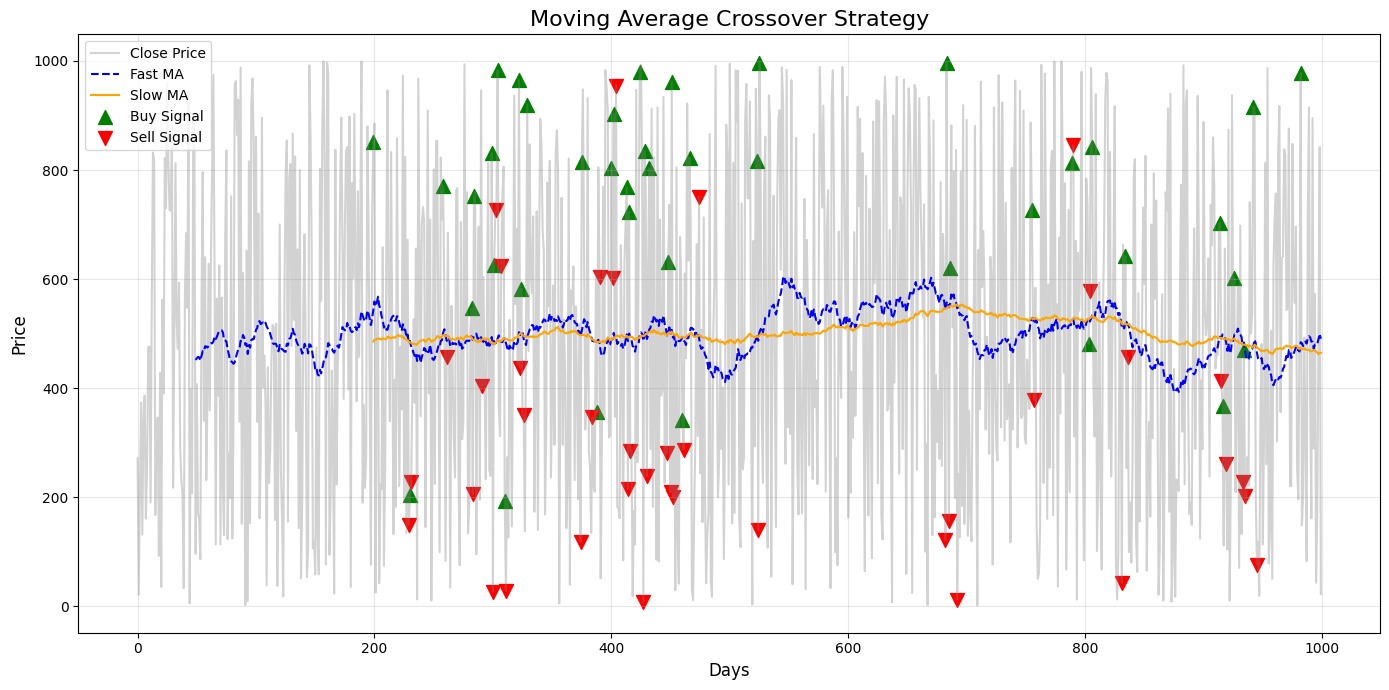

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Generate the random data (1000 rows, 4 columns)
np.random.seed(42)  # Added for reproducibility
Data = np.random.randint(1, 1000, (1000, 4))

# 2. Create the DataFrame with column names
df1 = pd.DataFrame(Data, columns=["Open", "High", "Low", "Close"])


# 3. Define the Signal Generation Function
def generate_ma_crossover_signals(
    data: pd.DataFrame, fast_window: int, slow_window: int
) -> pd.DataFrame:
    """Generates trading signals based on a Moving Average Crossover strategy."""
    df = data.copy()

    # Calculate the Moving Averages
    df["Fast_MA"] = df["Close"].rolling(window=fast_window).mean()
    df["Slow_MA"] = df["Close"].rolling(window=slow_window).mean()

    # Create a position flag: 1 when Fast is above Slow, 0 otherwise
    df["Position"] = np.where(df["Fast_MA"] > df["Slow_MA"], 1, 0)

    # The signal is the day-to-day change in position
    df["Signal"] = df["Position"].diff()

    # Clean up the NaN rows caused by the diff() and fill with 0 (Hold)
    df["Signal"] = df["Signal"].fillna(0).astype(int)

    # Clean up the intermediate 'Position' column
    df.drop(columns=["Position"], inplace=True)

    return df


# 4. Define the Visualization Function
def plot_signals(df: pd.DataFrame, save_path: str = "trading_strategy.png"):
    """Plots the Close price, Moving Averages, and Buy/Sell signals,
    and saves the output as an image.
    """
    plt.figure(figsize=(14, 7))

    # Plot Close Price and Moving Averages
    plt.plot(df.index, df["Close"], label="Close Price", alpha=0.35, color="gray")
    plt.plot(df.index, df["Fast_MA"], label="Fast MA", color="blue", linestyle="--")
    plt.plot(df.index, df["Slow_MA"], label="Slow MA", color="orange", linestyle="-")

    # Plot Buy Signals
    buy_signals = df[df["Signal"] == 1]
    plt.scatter(buy_signals.index, buy_signals["Close"], label="Buy Signal", marker="^", color="green", s=100)

    # Plot Sell Signals
    sell_signals = df[df["Signal"] == -1]
    plt.scatter(sell_signals.index, sell_signals["Close"], label="Sell Signal", marker="v", color="red", s=100)

    # Formatting
    plt.title("Moving Average Crossover Strategy", fontsize=16)
    plt.xlabel("Days", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # --- UPDATED: SAVE & PRINT ABSOLUTE PATH ---
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    # This automatically finds out exactly where the file landed
    absolute_path = os.path.abspath(save_path)
    print("\n" + "="*50)
    print(f" SUCCESS! Chart saved to its absolute path:\n {absolute_path}")
    print("="*50 + "\n")
    
    # Display the plot
    plt.show()


# 5. Run the strategy (e.g., 50-day and 200-day MA)
df_signals = generate_ma_crossover_signals(df1, fast_window=50, slow_window=200)

# 6. View the rows where a trade was triggered
print(df_signals[df_signals["Signal"] != 0].head())

# 7. Visualize and save the outcome
# NOTE: You can change "trading_strategy.png" to a full path if you want, 
# like r"C:\Users\YourName\Desktop\trading_strategy.png"
plot_signals(df_signals, save_path="trading_strategy.png")